<h1 id="Lecture-1:-Decision-to-evidence">Lecture 1: Decision to evidence</h1><p><strong>Class question:</strong> When should the café manager change staffing, and what evidence would justify the change?</p>
<p><strong>Unit:</strong> one 30-minute café service interval.  A chart can identify a pattern.  It cannot decide staffing on its own: the manager must consider cost, queue experience, and the operational options.</p>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ds301.paths import project_root
COURSE_ROOT = project_root()
TEAL, MINT, GOLD, CORAL, INK = "#005F73", "#0A9396", "#E9C46A", "#E76F51", "#1F2933"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})
cafe = pd.read_csv(COURSE_ROOT / "data/cafe_service.csv", parse_dates=["interval_start"])
cafe.head()

,interval_start,arrivals,staff_on_shift,mean_wait_minutes,satisfaction
0,2026-08-01 08:00:00,7,3,1.0,4.63
1,2026-08-01 08:30:00,5,3,1.0,4.70
2,2026-08-01 09:00:00,6,3,1.0,5.00
3,2026-08-01 09:30:00,5,3,1.0,4.88
4,2026-08-01 10:00:00,9,3,1.0,5.00


<h2 id="Begin-with-the-records">Begin with the records</h2><p>Every figure in this notebook follows the same trail: inspect the recorded event, choose a comparison that answers the decision question, then interpret the pattern with its limitation. The rows below are 30-minute service intervals. Before drawing a trend, check the fields, their units, and what one row means.</p>

In [2]:
cafe[["interval_start", "arrivals", "staff_on_shift", "mean_wait_minutes", "satisfaction"]].head(8)

,interval_start,arrivals,staff_on_shift,mean_wait_minutes,satisfaction
0,2026-08-01 08:00:00,7,3,1.0,4.63
1,2026-08-01 08:30:00,5,3,1.0,4.70
2,2026-08-01 09:00:00,6,3,1.0,5.00
3,2026-08-01 09:30:00,5,3,1.0,4.88
4,2026-08-01 10:00:00,9,3,1.0,5.00
5,2026-08-01 10:30:00,6,3,1.0,4.90
6,2026-08-01 11:00:00,7,3,1.0,5.00
7,2026-08-01 11:30:00,12,3,1.0,5.00


<h2 id="Build-an-evidence-chain">Build an evidence chain</h2><p>First name the decision, outcome, evidence, and limitation.  Then use the chart to ask a more precise question.</p>

In [3]:
summary = cafe.groupby("staff_on_shift").agg(
    intervals=("arrivals", "size"),
    mean_wait=("mean_wait_minutes", "mean"),
    mean_satisfaction=("satisfaction", "mean"),
).round(2)
summary

,intervals,mean_wait,mean_satisfaction
staff_on_shift,,,
3,191,1.37,4.90
4,19,2.76,4.65


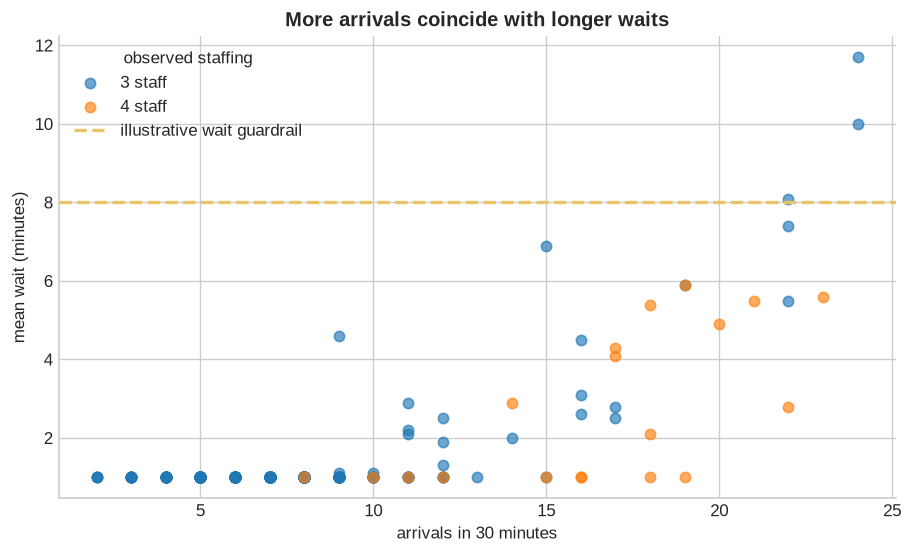

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for staff, group in cafe.groupby("staff_on_shift"):
    ax.scatter(group["arrivals"], group["mean_wait_minutes"], s=38, alpha=.65, label=f"{staff} staff")
ax.axhline(8, color=GOLD, lw=2, ls="--", label="illustrative wait guardrail")
ax.set(title="More arrivals coincide with longer waits", xlabel="arrivals in 30 minutes", ylabel="mean wait (minutes)")
ax.legend(title="observed staffing")
plt.show()

<h3 id="Student-activity">Student activity</h3><p>Work with a partner.  Choose a threshold you would investigate, state an outcome and guardrail, then name one reason this observational chart cannot prove that staffing caused the difference.</p>

In [5]:
peak = cafe.assign(peak=cafe.interval_start.dt.hour.between(12, 14)).groupby("peak").agg(
    mean_arrivals=("arrivals", "mean"), mean_wait=("mean_wait_minutes", "mean"), mean_satisfaction=("satisfaction", "mean")
)
peak

,mean_arrivals,mean_wait,mean_satisfaction
peak,,,
False,7.205556,1.093889,4.936889
True,17.366667,3.910000,4.492667


<h2 id="From-a-concern-to-an-action-ready-question">From a concern to an action-ready question</h2><p>Data science starts with a decision, then asks what evidence could reduce uncertainty. A dataset, dashboard, or algorithm does not create value on its own.</p>

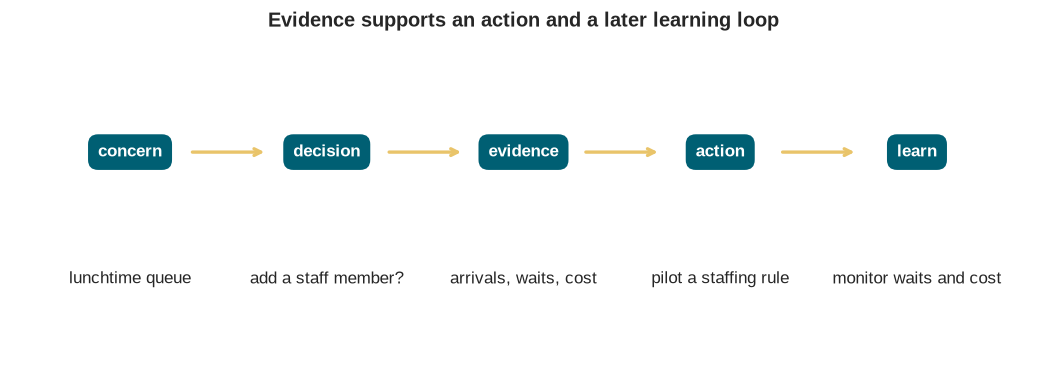

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.5))
steps = [("concern", "lunchtime queue"), ("decision", "add a staff member?"), ("evidence", "arrivals, waits, cost"), ("action", "pilot a staffing rule"), ("learn", "monitor waits and cost")]
for i, (heading, detail) in enumerate(steps):
    ax.text(i, .7, heading, ha="center", va="center", color="white", weight="bold", bbox=dict(boxstyle="round,pad=.6", fc=TEAL, ec="none"))
    ax.text(i, .15, detail, ha="center", va="center")
    if i < len(steps)-1: ax.annotate("",(i+.7,.7),(i+.3,.7),arrowprops=dict(arrowstyle="->",color=GOLD,lw=2))
ax.set(xlim=(-.6,4.6),ylim=(-.2,1.2),title="Evidence supports an action and a later learning loop"); ax.axis("off")
plt.show()

<h2 id="Comparison-makes-a-claim-meaningful">Comparison makes a claim meaningful</h2><p>“The queue is long” has no analytical reference. Compare a baseline, target, trend, segment, or benchmark before deciding what deserves investigation.</p>

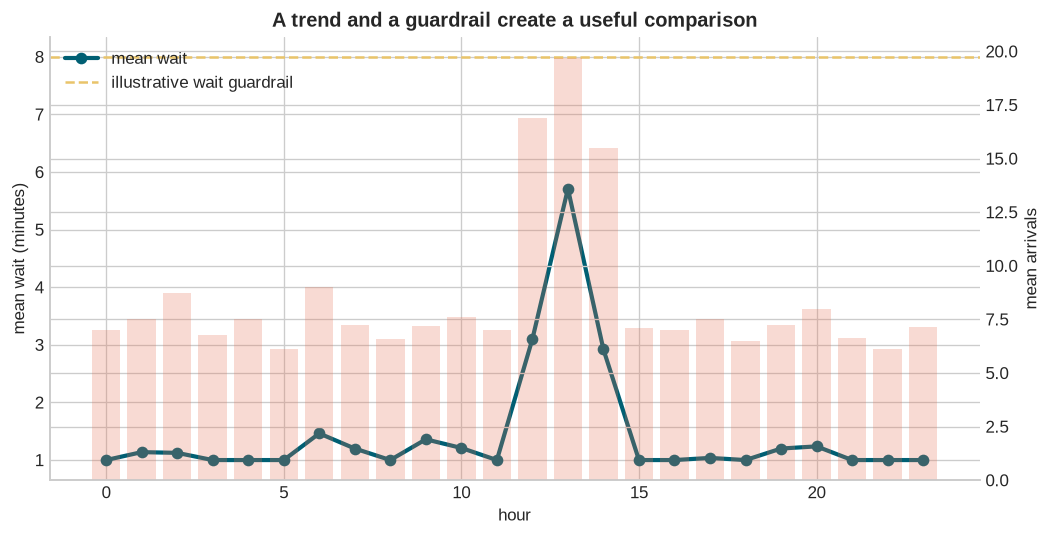

In [7]:
hourly = cafe.assign(hour=cafe.interval_start.dt.hour).groupby("hour").agg(wait=("mean_wait_minutes","mean"), arrivals=("arrivals","mean"))
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(hourly.index,hourly.wait,"o-",c=TEAL,lw=2.5,label="mean wait")
ax1.axhline(8,c=GOLD,ls="--",label="illustrative wait guardrail")
ax1.set(xlabel="hour",ylabel="mean wait (minutes)",title="A trend and a guardrail create a useful comparison")
ax2=ax1.twinx(); ax2.bar(hourly.index,hourly.arrivals,alpha=.25,color=CORAL,label="mean arrivals"); ax2.set_ylabel("mean arrivals")
ax1.legend(loc="upper left"); plt.show()

<h2 id="Data-science,-statistics,-analytics,-machine-learning,-and-AI">Data science, statistics, analytics, machine learning, and AI</h2><p>These overlap. The distinction helps us select a question and a method rather than treating a label as an answer.</p>

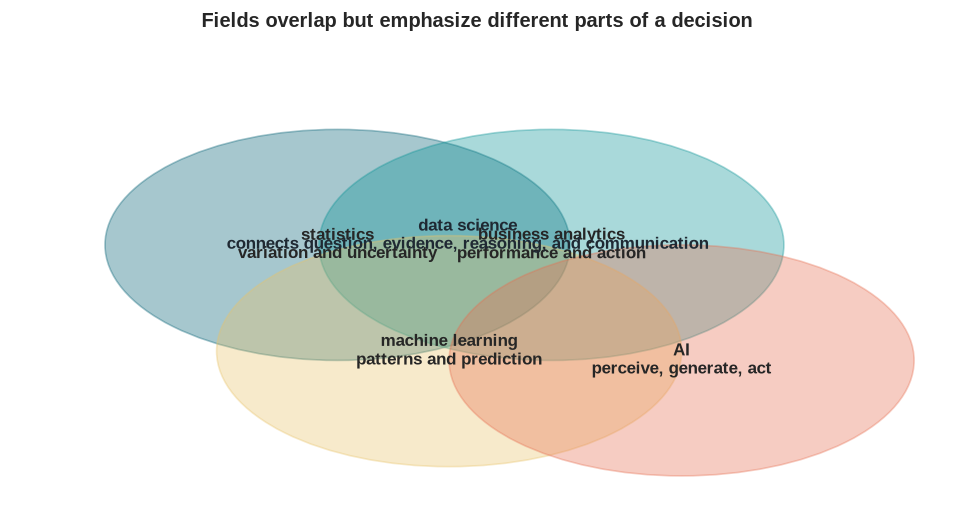

In [8]:
fig, ax=plt.subplots(figsize=(10,5))
circles=[((.35,.55),.25,"statistics\nvariation and uncertainty",TEAL),((.58,.55),.25,"business analytics\nperformance and action",MINT),((.47,.32),.25,"machine learning\npatterns and prediction",GOLD),((.72,.3),.25,"AI\nperceive, generate, act",CORAL)]
for (x,y),r,label,color in circles:
    ax.add_patch(plt.Circle((x,y),r,color=color,alpha=.35)); ax.text(x,y,label,ha="center",va="center",weight="bold")
ax.text(.49,.57,"data science\nconnects question, evidence, reasoning, and communication",ha="center",va="center",weight="bold",color=INK)
ax.set(xlim=(0,1),ylim=(0,1),title="Fields overlap but emphasize different parts of a decision"); ax.axis("off")
plt.show()

<h2 id="A-working-definition:-four-ingredients-used-together">A working definition: four ingredients used together</h2><p>Data science is useful when a decision is at stake, appropriate evidence can reduce uncertainty, an analytical approach fits the question, and the result can be communicated with its limits.</p>

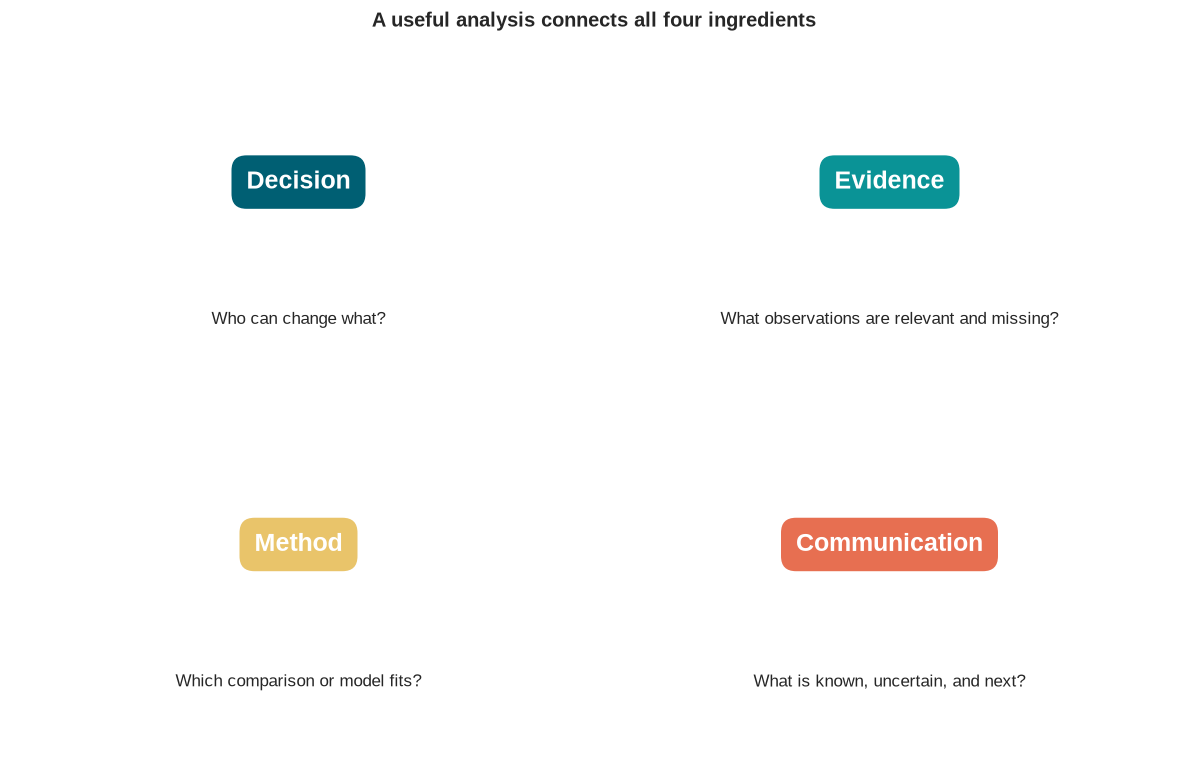

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))
ingredients = [
    ("Decision", "Who can change what?", TEAL),
    ("Evidence", "What observations are relevant and missing?", MINT),
    ("Method", "Which comparison or model fits?", GOLD),
    ("Communication", "What is known, uncertain, and next?", CORAL),
]
for ax, (name, prompt, colour) in zip(axes.ravel(), ingredients):
    ax.text(.5, .62, name, ha="center", va="center", weight="bold", color="white", fontsize=15,
            bbox=dict(boxstyle="round,pad=.6", fc=colour, ec="none"))
    ax.text(.5, .22, prompt, ha="center", va="center", wrap=True)
    ax.axis("off")
fig.suptitle("A useful analysis connects all four ingredients", weight="bold", y=.98)
plt.tight_layout()

<h2 id="A-dashboard-is-not-automatically-data-science">A dashboard is not automatically data science</h2><p>Use this checkpoint before investing in a large dataset, dashboard, or algorithm. If no decision or feasible action exists, begin with a conversation rather than a model.</p>

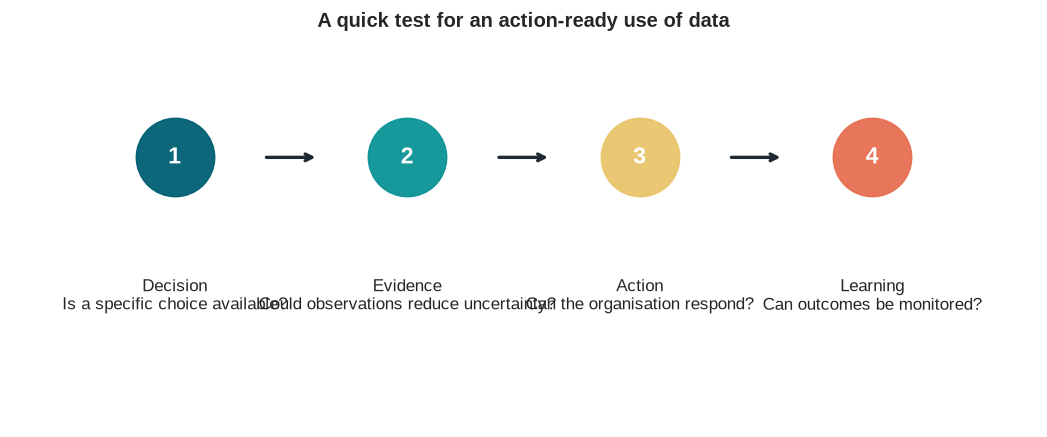

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.2))
checks = [
    ("Decision", "Is a specific choice available?"),
    ("Evidence", "Could observations reduce uncertainty?"),
    ("Action", "Can the organisation respond?"),
    ("Learning", "Can outcomes be monitored?"),
]
for i, (name, question) in enumerate(checks):
    ax.scatter(i, 1, s=2200, color=[TEAL, MINT, GOLD, CORAL][i], alpha=.95)
    ax.text(i, 1, str(i + 1), ha="center", va="center", color="white", weight="bold", fontsize=14)
    ax.text(i, .55, f"{name}\n{question}", ha="center", va="top", wrap=True)
    if i < len(checks) - 1:
        ax.annotate("", (i + .62, 1), (i + .38, 1), arrowprops=dict(arrowstyle="->", color=INK, lw=2))
ax.set(xlim=(-.7, 3.7), ylim=(0, 1.45), title="A quick test for an action-ready use of data")
ax.axis("off")
plt.show()

<h2 id="Responsible-use-begins-before-analysis-and-before-action">Responsible use begins before analysis and before action</h2><p>The first gate asks whether the purpose and data are legitimate. The second asks whether an action is accountable and safe enough to try.</p>

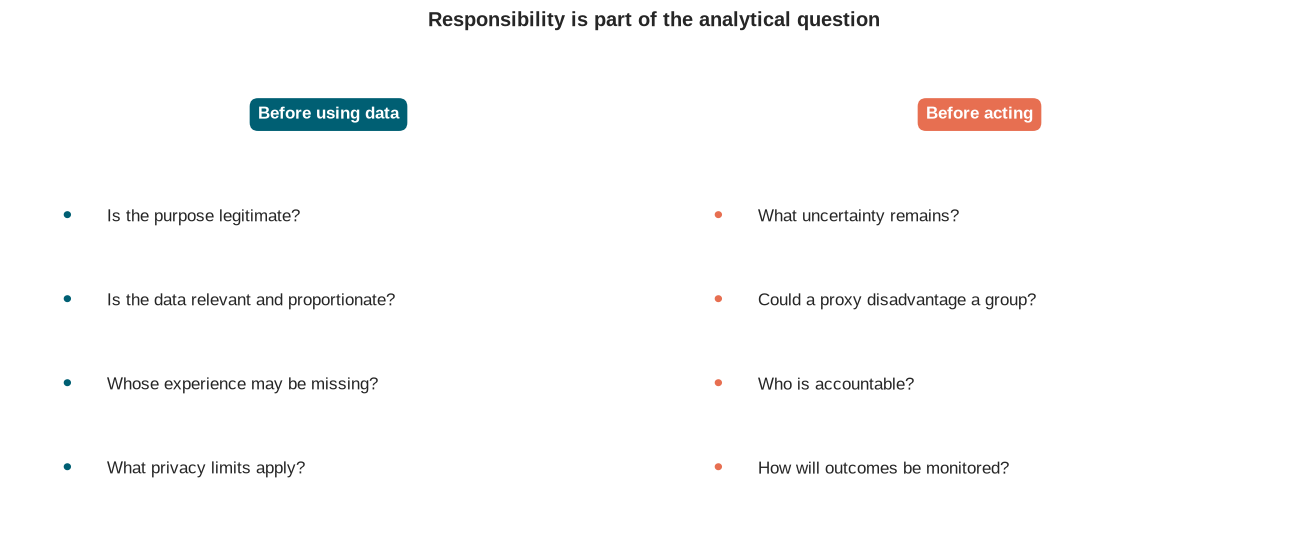

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
gates = [
    ("Before using data", ["Is the purpose legitimate?", "Is the data relevant and proportionate?", "Whose experience may be missing?", "What privacy limits apply?"], TEAL),
    ("Before acting", ["What uncertainty remains?", "Could a proxy disadvantage a group?", "Who is accountable?", "How will outcomes be monitored?"], CORAL),
]
for ax, (title, questions, colour) in zip(axes, gates):
    ax.text(.5, .92, title, ha="center", va="center", color="white", weight="bold",
            bbox=dict(boxstyle="round,pad=.5", fc=colour, ec="none"))
    for y, question in zip([.7, .52, .34, .16], questions):
        ax.text(.08, y, "•", color=colour, fontsize=16, va="center")
        ax.text(.15, y, question, va="center")
    ax.axis("off")
fig.suptitle("Responsibility is part of the analytical question", weight="bold", y=1.02)
plt.tight_layout()

<h2 id="Applied-evidence-trail:-a-real-dataset">Applied evidence trail: a real dataset</h2><p>The diabetes dataset bundled with scikit-learn contains measurements from a real clinical study. We use it only to practise an evidence trail, never to make a medical decision. One record describes one study participant. The target records disease progression one year later.</p>

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

diabetes = load_diabetes(as_frame=True)
raw_case = diabetes.frame.rename(columns={"target": "one-year progression"})
raw_case[["age", "bmi", "bp", "one-year progression"]].head(8)

,age,bmi,bp,one-year progression
0,0.038076,0.061696,0.021872,151.0
1,-0.001882,-0.051474,-0.026328,75.0
2,0.085299,0.044451,-0.005670,141.0
3,-0.089063,-0.011595,-0.036656,206.0
4,0.005383,-0.036385,0.021872,135.0
5,-0.092695,-0.040696,-0.019442,97.0
6,-0.045472,-0.047163,-0.015999,138.0
7,0.063504,-0.001895,0.066629,63.0


<p><strong>Raw records first.</strong> The standardised BMI value and later progression are individual observations. A fitted line can describe the association; it does not establish that changing BMI causes a change in progression.</p>

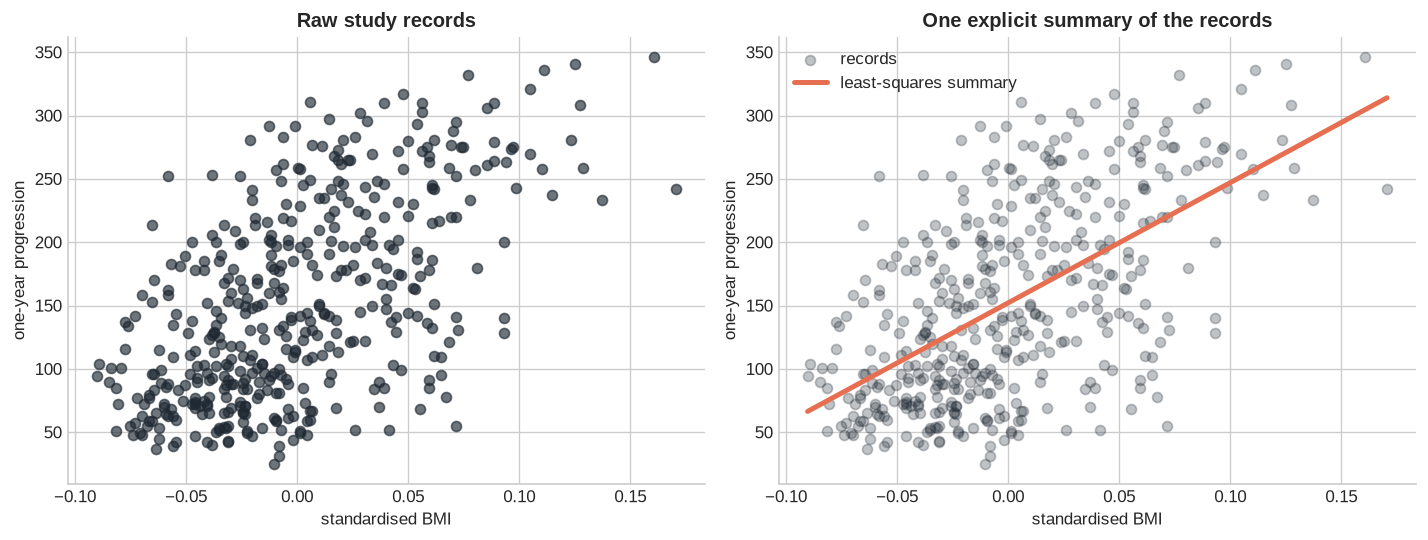

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(raw_case["bmi"], raw_case["one-year progression"], alpha=.65, color=INK)
axes[0].set(title="Raw study records", xlabel="standardised BMI", ylabel="one-year progression")
model = LinearRegression().fit(raw_case[["bmi"]], raw_case["one-year progression"])
grid = np.linspace(raw_case.bmi.min(), raw_case.bmi.max(), 200)
axes[1].scatter(raw_case["bmi"], raw_case["one-year progression"], alpha=.28, color=INK, label="records")
axes[1].plot(grid, model.predict(pd.DataFrame({"bmi": grid})), color=CORAL, lw=3, label="least-squares summary")
axes[1].set(title="One explicit summary of the records", xlabel="standardised BMI", ylabel="one-year progression")
axes[1].legend()
plt.tight_layout()

<p>The sequence is the reusable lesson: identify the unit, show the raw record, choose a summary that answers a question, and state what that summary cannot justify.</p>

### Lecture application

Connect each project output to the decision: raw measurement, descriptive comparison, prediction, then a proposed action. Explain which new evidence would justify using the prediction.

## Worked project: identifying wine cultivars from measured chemistry

**Question:** can chemical measurements identify the recorded cultivar of an unseen wine sample? The UCI Wine Recognition dataset has 178 measured samples, 13 input features and three cultivar labels. A laboratory could use such a model as a screening aid. This small historical sample cannot establish performance on every producer or future vintage.

We will inspect rows and units, reserve test records, establish a majority-class baseline, select a model using training folds, inspect errors, and write a decision statement. The class label is the outcome, so it never enters the feature matrix. No download is required because scikit-learn bundles these observations.

In [14]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
project_data = load_wine(as_frame=True)
project_X, project_y = project_data.data, project_data.target
display(project_data.frame.head(8))
display(pd.DataFrame({'dtype':project_X.dtypes.astype(str), 'missing':project_X.isna().sum(),
                      'minimum':project_X.min(), 'maximum':project_X.max()}).round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


,dtype,missing,minimum,maximum
alcohol,float64,0,11.03,14.83
malic_acid,float64,0,0.74,5.80
ash,float64,0,1.36,3.23
alcalinity_of_ash,float64,0,10.60,30.00
magnesium,float64,0,70.00,162.00
total_phenols,float64,0,0.98,3.88
flavanoids,float64,0,0.34,5.08
nonflavanoid_phenols,float64,0,0.13,0.66
proanthocyanins,float64,0,0.41,3.58
color_intensity,float64,0,1.28,13.00


### Inspect the observations before choosing a model

The scatter compares two recorded features. The counts show how many examples represent each class. A two-feature view may hide separation present in the other measurements. A random stratified split assumes that these records represent the unseen samples of interest; new producers or later vintages would need a different evaluation design.

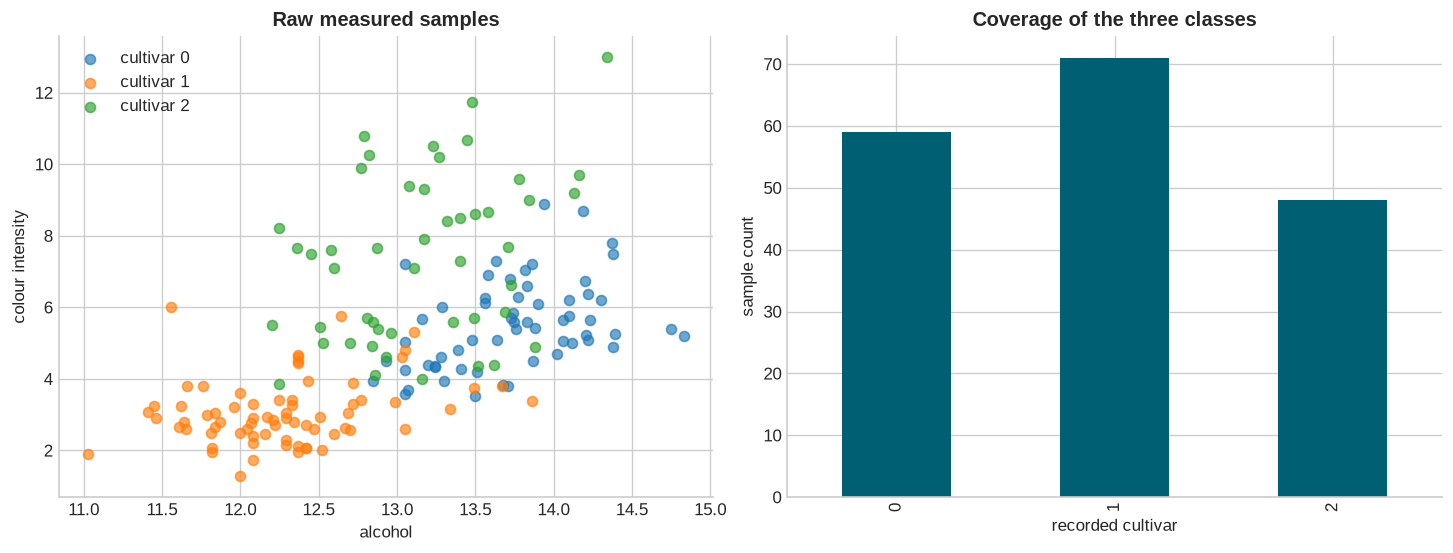

In [15]:
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for label in np.unique(project_y):
    selected = project_y==label
    axes[0].scatter(project_X.loc[selected,'alcohol'],project_X.loc[selected,'color_intensity'],label=f'cultivar {label}',alpha=.65)
axes[0].set(xlabel='alcohol',ylabel='colour intensity',title='Raw measured samples'); axes[0].legend()
project_y.value_counts().sort_index().plot.bar(ax=axes[1],color='#005F73')
axes[1].set(xlabel='recorded cultivar',ylabel='sample count',title='Coverage of the three classes'); plt.show()
project_train, project_test, target_train, target_test = train_test_split(project_X,project_y,test_size=.25,stratify=project_y,random_state=301)

### Fit a baseline, then select a model using training folds

The baseline always predicts the most common training class. The learned model scales features inside each training fold and estimates logistic probabilities. The validation table selects the regularisation setting using only training data. `C` is inverse regularisation strength: a smaller value applies stronger shrinkage.

,C,validation balanced accuracy,fold SD
0,0.01,0.981,0.026
1,0.10,0.981,0.026
2,1.00,0.972,0.026
3,10.00,0.964,0.022


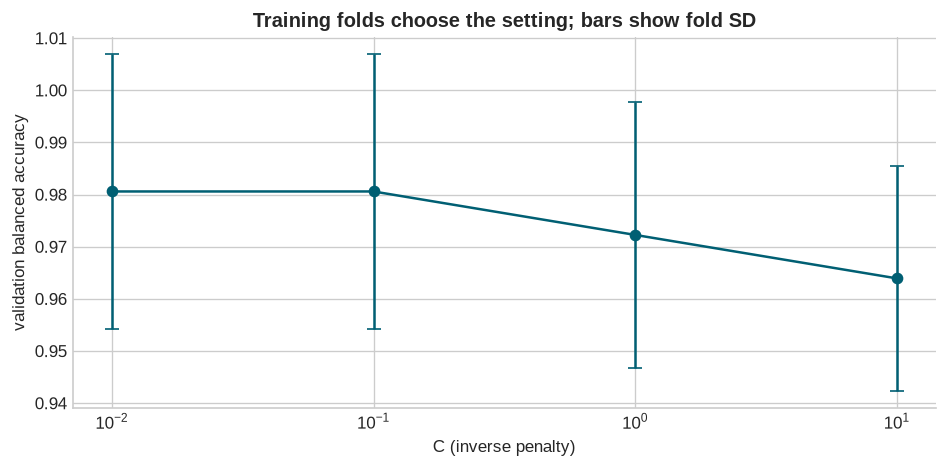

In [16]:
project_baseline = DummyClassifier(strategy='most_frequent').fit(project_train,target_train)
project_cv = StratifiedKFold(5,shuffle=True,random_state=301)
project_search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000)),
                             {'logisticregression__C':[.01,.1,1,10]},cv=project_cv,scoring='balanced_accuracy')
project_search.fit(project_train,target_train)
cv_table = pd.DataFrame(project_search.cv_results_)[['param_logisticregression__C','mean_test_score','std_test_score']]
display(cv_table.rename(columns={'param_logisticregression__C':'C','mean_test_score':'validation balanced accuracy','std_test_score':'fold SD'}).round(3))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(cv_table.iloc[:,0].astype(float),cv_table.iloc[:,1],yerr=cv_table.iloc[:,2],fmt='o-',capsize=4,color='#005F73')
ax.set(xscale='log',xlabel='C (inverse penalty)',ylabel='validation balanced accuracy',title='Training folds choose the setting; bars show fold SD')
plt.tight_layout(); plt.show()

### Open the held-out set once and inspect the errors

The confusion matrix counts actual outcomes, rather than compressing every error into one score. Each row refers to the true cultivar. Off-diagonal cells show which classes the fitted model confuses. These counts are small, so a high score on this split has substantial sampling uncertainty.

,model,test accuracy,test balanced accuracy
0,majority baseline,0.4,0.333
1,selected logistic model,1.0,1.000


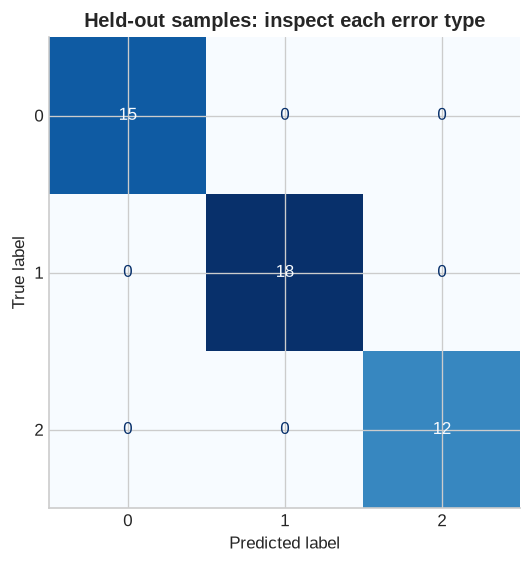

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,observed cultivar,predicted cultivar,highest probability
43,13.24,3.98,2.29,17.5,103.0,2.64,2.63,0.32,1.66,4.36,0.82,3.00,680.0,0,0,0.410
130,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2,0.436
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,0,0.490
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0,1,1,0.509
96,11.81,2.12,2.74,21.5,134.0,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625.0,1,1,0.537
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,1,0.540
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1,1,0.554
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0,1,1,0.555


In [17]:
project_pred = project_search.predict(project_test)
baseline_pred = project_baseline.predict(project_test)
display(pd.DataFrame({'model':['majority baseline','selected logistic model'],
                      'test accuracy':[accuracy_score(target_test,baseline_pred),accuracy_score(target_test,project_pred)],
                      'test balanced accuracy':[balanced_accuracy_score(target_test,baseline_pred),balanced_accuracy_score(target_test,project_pred)]}).round(3))
fig,ax=plt.subplots(figsize=(6,4.8))
ConfusionMatrixDisplay.from_predictions(target_test,project_pred,ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out samples: inspect each error type'); plt.tight_layout(); plt.show()
project_review=project_test.copy()
project_review['observed cultivar']=target_test
project_review['predicted cultivar']=project_pred
project_review['highest probability']=project_search.predict_proba(project_test).max(axis=1)
display(project_review.sort_values('highest probability').head(8).round(3))

### Decision statement and next evidence

Compare the selected model with the baseline using the table above. State the held-out sample size and the errors you see. A laboratory would next validate new samples from its own measurement process and agree when a prediction requires manual review. Monitoring would track missing measurements, feature ranges, class frequencies, and verified errors. Confidence scores need calibration evidence before they can justify an automatic acceptance threshold.